# Reinforcement Learning — Smart Charging eines Elektrotaxis

### Aufgabe 4: Intelligentes Laden mit Deep Q-Network und realen EPEX-Day-Ahead-Preisen

Ein Elektrotaxi kommt täglich um **14:00 Uhr** in der Garage an und fährt um **16:00 Uhr** wieder los.
In diesem Zwei-Stunden-Fenster entscheidet ein Ladeagent **alle 15 Minuten** (8 Intervalle), mit welcher
Leistung geladen wird. Ziel ist es, **die Ladekosten zu minimieren** und gleichzeitig **sicherzustellen,
dass genug Energie für den Arbeitstag** vorhanden ist.

**3-Wege-Vergleich**: **DQN** vs. **Greedy-Heuristik** vs. **preis-bewusster DQN**.

**Ziele**
- Minimierung der Ladekosten
- Sicherstellung, dass die Batterie genuegend Energie fuer den Arbeitstag enthaelt
- Vermeidung von Batteriemangel, der zu einer hohen Strafgebuehr fuehrt


### 1. Imports und Setup

Wir nutzen `gymnasium` für die Environment-Schnittstelle und `stable_baselines3` für das DQN-Training.

*Randnotiz (aus dem urspruenglichen Notebook):* "Gymnasium" leitet sich von "Gym" ab, also "Trainingshalle" -- der Agent trainiert darin wie in einer Sporthalle, indem er wiederholt mit der simulierten Umgebung interagiert: sie empfaengt eine Aktion und gibt den neuen Zustand, einen Reward und die Information zurueck, ob eine Episode beendet ist.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
torch.set_num_threads(1)

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

RNG_SEED = 42
np.random.seed(RNG_SEED)

os.makedirs('./logs/best_model_A', exist_ok=True)
os.makedirs('./logs/best_model_B', exist_ok=True)
print('Setup abgeschlossen. PyTorch-Threads:', torch.get_num_threads())

Setup abgeschlossen. PyTorch-Threads: 1


---
## Teil A — Vereinfachtes Kostenmodell ($\alpha_t \cdot e^p$)

Zunächst lösen wir das Problem exakt so, wie es in der Aufgabenstellung steht: die Ladekosten folgen
$$\text{charging cost}(t, p) = \sum_{t \in T} \alpha_t \, e^{p},$$
wobei $\alpha_t$ ein Zeitkoeffizient und $p$ die Ladeleistung ist.

### 2.1 Annahmen

| Größe | Wert | Bedeutung |
|-------|------|-----------|
| Batteriekapazität $C$ | {40, 60, 77} kWh | Gleichverteilt je Episode — kompakte, mittelgroße und große Fahrzeugklasse |
| Anfangs-SOC | $\mathcal{U}(20\%,\,60\%)$ von $C$ | Variiert täglich mit Schichtlänge und Streckenprofil |
| Ladefenster | 8 × 15 min | 14:00 – 16:00 Uhr |
| Ladeleistungen | {0, 5, 11, 22} kW | zero / low / medium / high |
| Energiebedarf $d$ | $\mathcal{N}(30, 5^2)$ kWh, gekappt bei $C$ | Fahrtbedarf hängt von der Route ab, nicht von der Fahrzeuggröße |
| Strafe | 100 €/kWh Mangel | sehr hohe Strafe bei zu wenig Energie |

**Zur Wahl der Kapazitätsstufen:** 40 kWh entspricht kompakten EVs (z. B. ältere Nissan Leaf / BMW i3),
60 kWh der Mittelklasse (z. B. VW ID.3, Tesla Model 3 SR) und 77 kWh größeren Fahrzeugen
(z. B. VW ID.4, Tesla Model 3 LR). Ein Flottenbetreiber besitzt typischerweise einen Mix dieser Klassen.

**Zur Variabilität des Anfangs-SOC:** In der Realität hängt der Ladestand bei Schichtende stark vom
Fahrtprofil des Tages ab. Ein Taxi, das viele kurze Stadtfahrten absolviert hat, kehrt mit deutlich mehr
Restladung zurück als eines nach einer mehrstündigen Überland- oder Flughafenfahrt. Eine feste 40-%-Annahme
würde diese tägliche Variabilität ignorieren und den Agenten auf ein zu eng definiertes Anfangsproblem
trainieren. Die Gleichverteilung $\mathcal{U}(20\%, 60\%)$ deckt die realistische Bandbreite ab:
- **20 %** entspricht einer fast leeren Batterie nach einer langen, streckenschweren Schicht.
- **60 %** entspricht einem Taxi nach einem leichten Tag mit vielen Kurzstrecken.

Da der Anfangs-SOC direkt im Zustandsvektor sichtbar ist, kann der Agent die Ladedringlichkeit von Beginn
an einschätzen und seine Strategie entsprechend anpassen.

**Konsequenz für die Schwierigkeit:** Kapazität und Anfangs-SOC werden unabhängig voneinander gezogen —
das erzeugt eine breite Palette von Episodentypen. Ein 40-kWh-Fahrzeug mit 20 % Anfangs-SOC (8 kWh) und
mittlerem Bedarf (30 kWh) muss 22 kWh in zwei Stunden laden — das ist eng, aber mit Volllast
(22 kW × 2 h = 44 kWh verfügbar) gerade noch machbar. Ein 77-kWh-Fahrzeug mit 60 % Anfangs-SOC
(46 kWh) hat dagegen kaum Nachladebedarf und kann stärker auf günstige Zeitschritte warten. Diese
Varianz ist gewollt: der Agent muss eine Strategie lernen, die sowohl unter Zeitdruck korrekt lädt als
auch bei komfortablem Puffer die Kosten optimiert.

### 2.2 Markov Decision Process

- **State** $s_t = [\text{SOC}_t,\; t,\; d,\; C]$ — Ladestand, Zeitschritt (0–8), Energiebedarf, Kapazität des Fahrzeugs
- **Action** $a \in \{0,5,11,22\}$ kW
- **Transition** $\text{SOC}_{t+1} = \min(C,\; \text{SOC}_t + a\cdot 0{,}25)$
- **Reward** negative Ladekosten pro Schritt; am Ende zusätzlich Strafe bei Mangel
- **Terminal** nach 8 Entscheidungen

**Herkunft dieser Annahmen.** Die erste Fassung (`04_reinforcement_learning.ipynb`) ging von einer einzigen festen Batteriekapazitaet aus: bei einem angenommenen mittleren Tagesbedarf von $\mu=30$ kWh ($\sigma=5$ kWh) wurde eine Sicherheitsreserve von 10-15 kWh aufgeschlagen und auf **50 kWh** aufgerundet, mit einem festen Anfangsladestand von **20 kWh** bei Ankunft. Mit 22 kW x 2 h = 44 kWh waere die Batterie ohne Kapazitaetsgrenze theoretisch um 44 kWh ladbar gewesen, tatsaechlich aber nur um 50 - 20 = 30 kWh. Diese feste Annahme deckte nur ein einzelnes Fahrzeug an einem durchschnittlichen Tag ab. Hier wird sie durch die drei Kapazitaetsklassen und den variablen Anfangs-SOC-Bereich ersetzt, um eine ganze Flotte und taegliche Schwankungen abzubilden.

### 2.3 Implementierung des Environments (Teil A)

In [2]:
class TaxiChargingEnvSimple(gym.Env):
    """
    Environment mit der vereinfachten Kostenfunktion alpha_t * exp(p).

    State : [SOC (kWh), Zeitschritt (0..8), Energiebedarf d (kWh), Kapazität C (kWh)]
    Action: Index in power_levels = [0, 5, 11, 22] kW
    Reward: -Ladekosten je Schritt; im letzten Schritt zusaetzlich -100 je fehlendem kWh
    """
    metadata = {'render_modes': []}

    CAPACITY_OPTIONS     = np.array([40.0, 60.0, 77.0])  # kWh: kompakt / Mittelklasse / groß
    INITIAL_SOC_FRAC_MIN = 0.20   # min SOC bei Ankunft (lange, streckenreiche Schicht)
    INITIAL_SOC_FRAC_MAX = 0.60   # max SOC bei Ankunft (kurze Stadtschicht)

    def __init__(self):
        super().__init__()
        self.max_steps    = 8    # Anzahl Ladeentscheidungen (2h / 15min = 8 Intervalle)
        self.interval_h   = 0.25 # ein Intervall = 15 Minuten = 0.25 Stunden
        self.power_levels = [0, 5, 11, 22]  # zero / low / medium / high (kW)
        self.demand_mean  = 30.0
        self.demand_std   = 5.0
        self.alpha_t = np.array(
            [2e-10, 2.4e-10, 2.9e-10, 3.5e-10,
             4.2e-10, 5.0e-10, 6.0e-10, 7.2e-10], dtype=np.float64)
        self.shortage_penalty = 100.0  # Strafe je fehlendem kWh am Ende der Episode

        cap_max = float(self.CAPACITY_OPTIONS.max())
        cap_min = float(self.CAPACITY_OPTIONS.min())
        self.action_space = spaces.Discrete(len(self.power_levels))
        self.observation_space = spaces.Box(
            low =np.array([0.0,     0.0, 0.0,     cap_min], dtype=np.float32),
            high=np.array([cap_max, 8.0, cap_max, cap_max], dtype=np.float32),
            dtype=np.float32)

        # Platzhalter — werden in reset() gesetzt
        self.capacity    = float(self.CAPACITY_OPTIONS.mean())
        self.initial_soc = 0.40 * self.capacity
        self.soc         = self.initial_soc
        self.current_step = 0
        self.demand      = self.demand_mean
        self.total_cost  = 0.0

    def _get_obs(self):
        return np.array([self.soc, float(self.current_step), self.demand, self.capacity],
                        dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.total_cost   = 0.0
        idx = int(self.np_random.integers(0, len(self.CAPACITY_OPTIONS)))
        self.capacity    = float(self.CAPACITY_OPTIONS[idx])
        soc_frac         = float(self.np_random.uniform(self.INITIAL_SOC_FRAC_MIN,
                                                         self.INITIAL_SOC_FRAC_MAX))
        self.initial_soc = soc_frac * self.capacity
        self.soc         = self.initial_soc
        self.demand = float(np.clip(
            self.np_random.normal(self.demand_mean, self.demand_std), 0.0, self.capacity))
        return self._get_obs(), {}

    def step(self, action):
        power = self.power_levels[int(action)]
        previous_soc = self.soc
        self.soc = min(self.capacity, self.soc + power * self.interval_h)
        actual_energy_added = self.soc - previous_soc

        alpha = self.alpha_t[self.current_step]
        charging_cost = alpha * np.exp(float(power)) if power > 0 else 0.0
        self.total_cost += charging_cost
        reward = -charging_cost

        self.current_step += 1
        terminated = False
        info = {'power': power, 'energy_added': actual_energy_added,
                'charging_cost': charging_cost, 'total_cost': self.total_cost,
                'soc': self.soc, 'demand': self.demand, 'capacity': self.capacity}

        if self.current_step >= self.max_steps:
            shortage = max(0.0, self.demand - self.soc)
            reward -= self.shortage_penalty * shortage
            info.update({'shortage': shortage, 'success': shortage == 0.0, 'final_soc': self.soc})
            terminated = True
        return self._get_obs(), float(reward), terminated, False, info


Initiale Kostenformel $\alpha_t \cdot e^{p}$ direkt mit den in der Aufgabenstellung genannten Groessenordnungen $\alpha_t \in [0{,}006,\,0{,}02]$ und $p$ in kW eingesetzt. Das Ergebnis: Bei 22 kW explodiert $e^{22}$ und die Ladekosten liegen um Groessenordnungen ueber der Mangel-Strafe (siehe Rechnung unten). Der trainierte DQN-Agent lernte daraufhin, in **100 % der Faelle 0 kW** zu waehlen -- eine Erfolgsquote von nur **2,80 %**. Eine erste Korrektur skalierte die Leistung im Exponenten ($e^{p/5}$ statt $e^{p}$) und erreichte damit **98,50 %** Erfolgsquote. Hier wird Statt die Exponentialfunktion zu veraendern, sind die $\alpha_t$-Konstanten selbst von vornherein sehr klein gewaehlt (siehe Environment oben, $\alpha_t \in [2\cdot10^{-10},\,7{,}2\cdot10^{-10}]$).

In [ ]:
print("=== Vorversion: unskalierte Kostenfunktion (Groessenordnung aus der Aufgabenstellung) ===")
alpha_naive = np.array([0.006, 0.007, 0.008, 0.010, 0.012, 0.014, 0.017, 0.020])
worst_naive = sum(a * np.exp(22) for a in alpha_naive)
print(f"Maximale Ladekosten (8 x 22 kW, alpha ~ 0.006-0.02, ohne Skalierung): {worst_naive:.3e}")
print(f"Strafe je fehlendem kWh: {TaxiChargingEnvSimple().shortage_penalty:.0f}")
print("=> Ladekosten liegen um Groessenordnungen ueber der Strafe - der Agent lernt, gar nicht zu laden.")

=== Vorversion: unskalierte Kostenfunktion (Groessenordnung aus der Aufgabenstellung) ===
Maximale Ladekosten (8 x 22 kW, alpha ~ 0.006-0.02, ohne Skalierung): 3.370e+08
Strafe je fehlendem kWh: 100
=> Ladekosten liegen um Groessenordnungen ueber der Strafe - der Agent lernt, gar nicht zu laden.


**Plausibilitätsprüfung der Kostenskalierung.** Wir vergewissern uns, dass Laden günstiger ist als die Strafe.

In [3]:
env_tmp = TaxiChargingEnvSimple()
worst = sum(a * np.exp(22) for a in env_tmp.alpha_t)
print(f'Maximale Ladekosten (8 x 22 kW): {worst:6.2f} Reward-Einheiten')
print(f'Strafe je fehlendem kWh        : {env_tmp.shortage_penalty:6.0f} Reward-Einheiten')
print(f'Verhaeltnis Strafe / Maximalkosten: {env_tmp.shortage_penalty / worst:5.1f}x')
print('=> Ausreichendes Laden lohnt sich immer gegenueber dem Strafrisiko.')

Maximale Ladekosten (8 x 22 kW):  11.90 Reward-Einheiten
Strafe je fehlendem kWh        :    100 Reward-Einheiten
Verhaeltnis Strafe / Maximalkosten:   8.4x
=> Ausreichendes Laden lohnt sich immer gegenueber dem Strafrisiko.


### 3. Greedy-Heuristik (gemeinsame Baseline)

Die Heuristik ist **preis-unabhängig**: Sie verteilt den noch fehlenden Energiebedarf gleichmäßig auf die
verbleibenden Zeitschritte und wählt die kleinste Leistung, die das schafft. Diese Regel ist intuitiv und
dient in **beiden** Teilen als untere Schranke. Genau hier entscheidet sich, ob RL einen Mehrwert hat: Solange
jede kWh gleich viel kostet, ist „gleichmäßig auffüllen" nahezu optimal — sobald Preise schwanken, nicht mehr.

In [4]:
def greedy_episode(env, seed=None):
    """Greedy: fuelle den fehlenden Bedarf gleichmaessig auf die Restschritte auf (preis-unabhaengig)."""
    obs, _ = env.reset(seed=seed)
    done = False
    ep_reward = 0.0
    soc_traj = [float(obs[0])]
    info = {}
    while not done:
        soc, step, demand = float(obs[0]), int(obs[1]), float(obs[2])
        remaining = env.max_steps - step
        if soc >= demand:
            action = 0
        else:
            needed_kw = (demand - soc) / (remaining * env.interval_h)
            action = len(env.power_levels) - 1
            for i, p in enumerate(env.power_levels):
                if p >= needed_kw:
                    action = i
                    break
        obs, reward, done, _, info = env.step(int(action))
        ep_reward += reward
        soc_traj.append(float(obs[0]))
    return ep_reward, bool(info.get('success', False)), soc_traj


### 4. Exaktes Optimum per Brute-Force (absoluter Maßstab)

Der Aktionsraum ist winzig: 4 Aktionen über 8 Schritte = $4^8 = 65\,536$ mögliche Ladepläne. Für eine gegebene
Episode (fester Bedarf, feste Preise) können wir daher **alle Pläne durchprobieren** und den kostenoptimalen
Plan finden, der den Bedarf deckt. Das liefert eine echte Obergrenze für den erreichbaren Reward — relativ dazu
messen wir, wie gut DQN und Greedy *wirklich* sind, statt sie nur miteinander zu vergleichen.

In [5]:
from itertools import product

def optimal_episode_reward(env_proto, demand, price_vector=None):
    """
    Bestimmt per Brute-Force den maximal erreichbaren Episode-Reward fuer einen
    gegebenen Bedarf (und optional einen Preisvektor fuer Teil B).
    env_proto liefert nur die Parameter (Kapazitaet, power_levels, ...).
    """
    cap   = env_proto.capacity
    soc0  = env_proto.initial_soc
    ih    = env_proto.interval_h
    P     = env_proto.power_levels
    pen   = env_proto.shortage_penalty
    n     = env_proto.max_steps
    alpha = env_proto.alpha_t if price_vector is None else None

    best = -np.inf
    for plan in product(range(len(P)), repeat=n):
        soc = soc0
        cost = 0.0
        for t, a in enumerate(plan):
            p = P[a]
            new_soc = min(cap, soc + p * ih)
            if price_vector is None:                    # Teil A: alpha_t * exp(p)
                cost += alpha[t] * np.exp(float(p)) if p > 0 else 0.0
            else:                                       # Teil B: Preis * tatsaechlich geladene Energie
                cost += price_vector[t] * (new_soc - soc)
            soc = new_soc
        shortage = max(0.0, demand - soc)
        reward = -cost - pen * shortage
        if reward > best:
            best = reward
    return best


### 5. DQN-Agent trainieren (Teil A)

Deep Q-Learning approximiert die Aktionswertfunktion $Q(s,a)$ mit einem neuronalen Netz. Ein `EvalCallback`
verfolgt die Lernkurve. Bei 8 Schritten/Episode entsprechen 200 000 Zeitschritte ca. 25 000 simulierten Tagen.

**Entwicklung der Hyperparameter.** Die erste Version (`04_reinforcement_learning.ipynb`) trainierte mit einfacheren Einstellungen (`learning_rate=0.001`, `buffer_size=10000`, `batch_size=64`, 50 000 Zeitschritte, kein Eval-Callback) und ohne heterogene Flotte. Hier wird laenger (200 000 Zeitschritte) und mit groesserem Buffer, groesserem Netz (`[128, 128]`) sowie einem `EvalCallback` fuer eine sauber protokollierte Lernkurve trainiert.

In [6]:
train_env_A = Monitor(TaxiChargingEnvSimple())
eval_env_A  = Monitor(TaxiChargingEnvSimple())

eval_cb_A = EvalCallback(eval_env_A, best_model_save_path='./logs/best_model_A',
                         log_path='./logs/log_A', eval_freq=2_000,
                         n_eval_episodes=200, deterministic=True, render=False, verbose=0)

model_A = DQN('MlpPolicy', train_env_A,
              learning_rate=5e-4, buffer_size=50_000, learning_starts=2_000,
              batch_size=128, gamma=0.99, train_freq=4, target_update_interval=500,
              exploration_fraction=0.2, exploration_final_eps=0.02,
              policy_kwargs=dict(net_arch=[128, 128]), seed=RNG_SEED, verbose=0)

model_A.learn(total_timesteps=200_000, callback=eval_cb_A)
model_A.save('taxi_charging_dqn_simple')
print('Teil-A-Training abgeschlossen.')

Teil-A-Training abgeschlossen.


### 6. Paarweise Evaluation (Teil A)

DQN und Greedy werden auf **identischen** Episoden (gleiche Seeds → gleicher Bedarf) evaluiert, sodass der Reward *pro Episode gepaart* verglichen wird. Für eine Teilmenge wird zusätzlich das exakte Brute-Force-Optimum berechnet.

In [7]:
def evaluate_dqn(model, env, seeds):
    rewards, successes, trajs = [], [], []
    action_counts = np.zeros(len(env.power_levels))
    for sd in seeds:
        obs, _ = env.reset(seed=int(sd))
        done = False
        ep_r = 0.0
        traj = [float(obs[0])]
        info = {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action = int(action)
            action_counts[action] += 1
            obs, reward, done, _, info = env.step(action)
            ep_r += reward
            traj.append(float(obs[0]))
        rewards.append(ep_r)
        successes.append(bool(info.get('success', False)))
        trajs.append(traj)
    return (np.array(rewards), np.array(successes), np.array(trajs), action_counts)

N_EVAL = 1000
eval_seeds = np.arange(10_000, 10_000 + N_EVAL)

# DQN
dqn_env_A = TaxiChargingEnvSimple()
dqnA_r, dqnA_s, dqnA_traj, dqnA_actions = evaluate_dqn(model_A, dqn_env_A, eval_seeds)

# Greedy auf identischen Seeds
grd_env_A = TaxiChargingEnvSimple()
grd_results_A = [greedy_episode(grd_env_A, seed=int(sd)) for sd in eval_seeds]
grdA_r, grdA_s, grdA_traj = [np.array(x) for x in zip(*grd_results_A)]

# Exaktes Optimum auf einer Teilmenge (Brute-Force ist teuer)
opt_proto = TaxiChargingEnvSimple()
opt_seeds = eval_seeds[:100]
optA = []
for sd in opt_seeds:
    o, _ = opt_proto.reset(seed=int(sd))
    optA.append(optimal_episode_reward(opt_proto, demand=float(o[2])))
optA = np.array(optA)

n_opt = len(optA)
print('=== Teil A: Ergebnisse (1000 gepaarte Episoden) ===')
print(f'DQN     | Erfolg {dqnA_s.mean()*100:5.1f}% | Reward {dqnA_r.mean():7.3f} +/- {dqnA_r.std():.3f}')
print(f'Greedy  | Erfolg {grdA_s.mean()*100:5.1f}% | Reward {grdA_r.mean():7.3f} +/- {grdA_r.std():.3f}')
print(f'--- Vergleich auf identischen {n_opt} Episoden (Brute-Force-Subset) ---')
print(f'Greedy  (n={n_opt})              | Reward {grdA_r[:n_opt].mean():7.3f}')
print(f'Optimum (n={n_opt}, Brute-Force) | Reward {optA.mean():7.3f}')
diff = dqnA_r - grdA_r
print(f'\nGepaarte Differenz (DQN - Greedy): {diff.mean():+.4f}  '
      f'95%-CI [{diff.mean()-1.96*diff.std()/np.sqrt(N_EVAL):+.4f}, '
      f'{diff.mean()+1.96*diff.std()/np.sqrt(N_EVAL):+.4f}]')


=== Teil A: Ergebnisse (1000 gepaarte Episoden) ===
DQN     | Erfolg  96.0% | Reward  -8.810 +/- 57.354
Greedy  | Erfolg 100.0% | Reward  -0.068 +/- 0.361
--- Vergleich auf identischen 100 Episoden (Brute-Force-Subset) ---
Greedy  (n=100)              | Reward  -0.198
Optimum (n=100, Brute-Force) | Reward  -0.198

Gepaarte Differenz (DQN - Greedy): -8.7413  95%-CI [-12.2770, -5.2055]


### 7. Beispiel-Episode

Der folgende Trace zeigt den Ladepfad des DQN-Agenten für eine einzelne Episode: Schritt für Schritt Zeitpunkt, gewählte Ladeleistung, tatsächlich geladene Energie, anfallende Kosten und resultierender Ladezustand.

In [8]:
trace_env = TaxiChargingEnvSimple()
obs, _ = trace_env.reset(seed=0)
trace, done = [], False

while not done:
    old_soc  = float(obs[0])
    old_step = int(obs[1])
    action, _ = model_A.predict(obs, deterministic=True)
    obs, reward, done, _, info = trace_env.step(int(action))
    trace.append({
        'Schritt':               old_step,
        'Uhrzeit':               f'{14 + old_step*0.25:05.2f}',
        'Kapazität (kWh)':       int(info['capacity']),
        'SOC vorher (kWh)':      round(old_soc, 2),
        'Aktion (kW)':           int(info['power']),
        'Energie geladen (kWh)': round(float(info['energy_added']), 3),
        'Ladekosten':            round(float(info['charging_cost']), 8),
        'SOC nachher (kWh)':     round(float(info['soc']), 2),
        'Reward':                round(float(reward), 4),
        'Bedarf (kWh)':          round(float(info['demand']), 2),
        'Mangel (kWh)':          round(float(info.get('shortage', 0.0)), 2),
        'Erfolgreich':           bool(info['success']) if done else False,
    })

df_trace_A = pd.DataFrame(trace)
df_trace_A

,Schritt,Uhrzeit,Kapazität (kWh),SOC vorher (kWh),Aktion (kW),Energie geladen (kWh),Ladekosten,SOC nachher (kWh),Reward,Bedarf (kWh),Mangel (kWh),Erfolgreich
0,0,14.00,77,23.71,11,2.75,1.197000e-05,26.46,-0.0,33.2,0.0,False
1,1,14.25,77,26.46,11,2.75,1.437000e-05,29.21,-0.0,33.2,0.0,False
2,2,14.50,77,29.21,11,2.75,1.736000e-05,31.96,-0.0,33.2,0.0,False
3,3,14.75,77,31.96,11,2.75,2.096000e-05,34.71,-0.0,33.2,0.0,False
4,4,15.00,77,34.71,11,2.75,2.515000e-05,37.46,-0.0,33.2,0.0,False
5,5,15.25,77,37.46,5,1.25,7.000000e-08,38.71,-0.0,33.2,0.0,False
6,6,15.50,77,38.71,5,1.25,9.000000e-08,39.96,-0.0,33.2,0.0,False
7,7,15.75,77,39.96,5,1.25,1.100000e-07,41.21,-0.0,33.2,0.0,True


**Zwischenfazit Teil A.** Bei konstanten Energiekosten pro kWh (die $\alpha_t$ variieren nur minimal) ist
das Problem strukturell einfach: „fehlenden Bedarf gleichmäßig auffüllen" ist nahezu optimal. Wir erwarten
daher, dass DQN und Greedy **etwa gleichauf** liegen und beide nahe am Brute-Force-Optimum sind. Das ist **kein
Versagen** des RL-Ansatzes, sondern ein valider Befund: *Für dieses vereinfachte Kostenmodell ist RL nicht
nötig.* Die spannende Frage stellt Teil B.


---
## Teil B — Reale EPEX-Day-Ahead-Preise

Jetzt ersetzen wir die künstliche Kostenfunktion durch **echte Strompreise**. Statt $\alpha_t \cdot e^p$ kostet
das Laden nun
$$\text{cost}(t, p) = \pi_t \cdot (p \cdot \Delta t),$$
also **Preis $\pi_t$ (€/kWh) × tatsächlich geladene Energie**. Der Preis $\pi_t$ schwankt über den Tag — und
**jede Episode zieht einen anderen realen Tag**. Damit muss der Agent eine *preis-bewusste* Strategie lernen:
laden, wenn es billig ist, warten, wenn es teuer ist — solange am Ende der Bedarf gedeckt ist.

### 8. Datenquelle und -aufbereitung

**Quelle:** Fraunhofer ISE *Energy-Charts* API (Daten von ENTSO-E / EPEX SPOT, Lizenz CC BY 4.0).
**Zeitraum:** Q1 2025 (Januar–März), Gebotszone **DE-LU**, stündliche Day-Ahead-Preise.
**Fenster:** Pro Tag werden die Stunden 14:00–15:00 und 15:00–16:00 verwendet. Die stündlichen Preise werden **linear auf vier Viertelstunden-Schritte interpoliert** — d. h. der Preis steigt oder fällt innerhalb jeder Stunde gleichmäßig zum nächsten Stundenwert, statt für alle vier Schritte konstant zu bleiben. Das Ergebnis wird als `epex_windows_q1_2025.npy` gespeichert.

In [9]:
import requests, pandas as pd, numpy as np

def fetch_epex_dayahead(start="2025-01-01", end="2025-03-31", bzn="DE-LU"):
    url = f"https://api.energy-charts.info/price?bzn={bzn}&start={start}&end={end}"
    data = requests.get(url, timeout=30).json()
    ts    = pd.to_datetime(data["unix_seconds"], unit="s", utc=True).tz_convert("Europe/Berlin")
    price = np.array(data["price"], dtype=float) / 1000.0   # EUR/MWh -> EUR/kWh
    s = pd.Series(price, index=ts)
    # Pro Tag die Stunden 14, 15 und 16 nehmen und linear auf Viertelstunden interpolieren
    days = []
    for day, grp in s.groupby(s.index.date):
        h14 = grp[grp.index.hour == 14]
        h15 = grp[grp.index.hour == 15]
        h16 = grp[grp.index.hour == 16]
        if len(h14) and len(h15) and len(h16):
            p14, p15, p16 = h14.iloc[0], h15.iloc[0], h16.iloc[0]
            # np.linspace(a, b, 5)[:-1] gibt [a, a+d, a+2d, a+3d] mit d=(b-a)/4
            window = (list(np.linspace(p14, p15, 5)[:-1]) +
                      list(np.linspace(p15, p16, 5)[:-1]))
            days.append(window)
    return np.array(days)                                  # shape (n_days, 8)

EPEX_WINDOWS = fetch_epex_dayahead()
np.save("epex_windows_q1_2025.npy", EPEX_WINDOWS)
print(f'Preisfenster geladen: {EPEX_WINDOWS.shape} (Tage, Schritte)')
print(f'Preis-Spannweite (EUR/kWh): min={EPEX_WINDOWS.min():.3f}, '
      f'median={np.median(EPEX_WINDOWS):.3f}, max={EPEX_WINDOWS.max():.3f}')

Preisfenster geladen: (90, 8) (Tage, Schritte)
Preis-Spannweite (EUR/kWh): min=-0.026, median=0.110, max=0.371


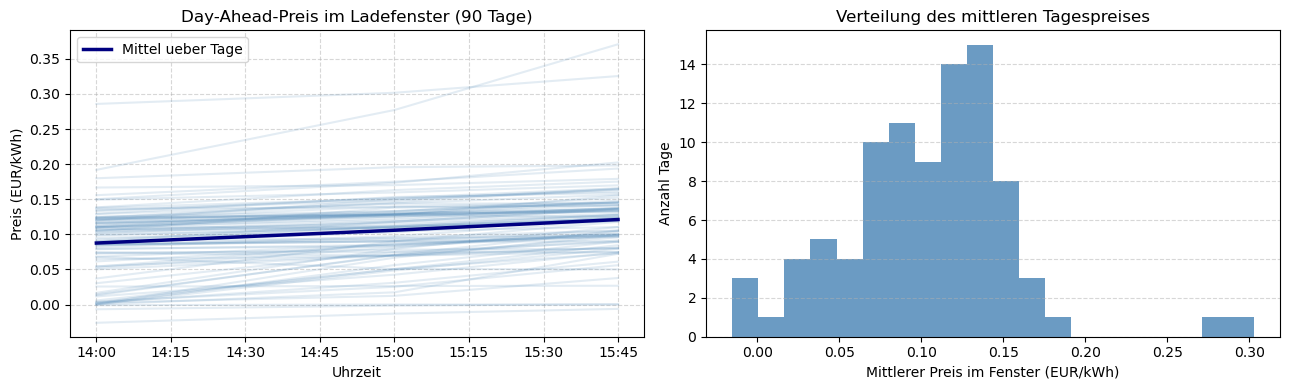

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_days = len(EPEX_WINDOWS)
steps = np.arange(8)
time_labels = ['14:00', '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45']

for w in EPEX_WINDOWS:
    ax[0].plot(steps, w, color='steelblue', alpha=0.15)
ax[0].plot(steps, EPEX_WINDOWS.mean(axis=0), color='navy', lw=2.5, label='Mittel ueber Tage')
ax[0].set_title(f'Day-Ahead-Preis im Ladefenster ({n_days} Tage)')
ax[0].set_xlabel('Uhrzeit')
ax[0].set_ylabel('Preis (EUR/kWh)')
ax[0].set_xticks(steps)
ax[0].set_xticklabels(time_labels)
ax[0].legend(); ax[0].grid(True, ls='--', alpha=0.5)

ax[1].hist(EPEX_WINDOWS.mean(axis=1), bins=20, color='steelblue', alpha=0.8)
ax[1].set_title('Verteilung des mittleren Tagespreises')
ax[1].set_xlabel('Mittlerer Preis im Fenster (EUR/kWh)')
ax[1].set_ylabel('Anzahl Tage')
ax[1].grid(True, axis='y', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


### 9. Preis-bewusstes Environment (Teil B)

Zwei entscheidende Änderungen gegenüber Teil A:
1. **Kosten = realer Preis × geladene Energie** (statt $\alpha_t e^p$).
2. **Der aktuelle Preis ist Teil des Zustands.** Ohne Preis im State *kann* der Agent gar nicht preis-bewusst
   handeln — diese Erweiterung ist die eigentliche Voraussetzung dafür, dass RL die Heuristik schlagen kann.
   Wir geben dem Agenten den Preis des aktuellen Schritts **und** den mittleren Restpreis mit, damit er
   „billig jetzt vs. später" abwägen kann.

**State** $s_t = [\text{SOC}_t,\; t,\; d,\; C,\; \pi_t,\; \bar\pi_{>t}]$.

In [11]:
class TaxiChargingEnvEPEX(gym.Env):
    """
    Preis-bewusstes Environment mit realen EPEX-Day-Ahead-Preisen und heterogener Flotte.

    State : [SOC (kWh), Zeitschritt, Bedarf d (kWh), Kapazität C (kWh), Preis jetzt, Ø Restpreis]
    Action: Index in power_levels = [0, 5, 11, 22] kW
    Reward: -Preis * geladene Energie je Schritt; am Ende -100 je fehlendem kWh
    """
    metadata = {'render_modes': []}

    CAPACITY_OPTIONS     = np.array([40.0, 60.0, 77.0])
    INITIAL_SOC_FRAC_MIN = 0.20   # min SOC bei Ankunft (lange, streckenreiche Schicht)
    INITIAL_SOC_FRAC_MAX = 0.60   # max SOC bei Ankunft (kurze Stadtschicht)

    def __init__(self, price_windows):
        super().__init__()
        self.price_windows = np.asarray(price_windows, dtype=np.float64)
        self.max_steps    = 8
        self.interval_h   = 0.25
        self.power_levels = [0, 5, 11, 22]
        self.demand_mean  = 30.0
        self.demand_std   = 5.0
        self.shortage_penalty = 100.0

        cap_max = float(self.CAPACITY_OPTIONS.max())
        cap_min = float(self.CAPACITY_OPTIONS.min())
        pmax    = float(self.price_windows.max()) * 1.5
        self.action_space = spaces.Discrete(len(self.power_levels))
        self.observation_space = spaces.Box(
            low =np.array([0.0,     0.0, 0.0,     cap_min, 0.0,  0.0  ], dtype=np.float32),
            high=np.array([cap_max, 8.0, cap_max, cap_max, pmax, pmax  ], dtype=np.float32),
            dtype=np.float32)

        # Platzhalter — werden in reset() gesetzt
        self.capacity    = float(self.CAPACITY_OPTIONS.mean())
        self.initial_soc = 0.40 * self.capacity
        self.soc         = self.initial_soc
        self.current_step = 0
        self.demand      = self.demand_mean
        self.prices      = self.price_windows[0]
        self.total_cost  = 0.0

    def _mean_remaining_price(self):
        if self.current_step >= self.max_steps:
            return 0.0
        return float(self.prices[self.current_step:].mean())

    def _get_obs(self):
        price_now = float(self.prices[self.current_step]) if self.current_step < self.max_steps else 0.0
        return np.array([self.soc, float(self.current_step), self.demand, self.capacity,
                         price_now, self._mean_remaining_price()], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.total_cost   = 0.0
        idx = int(self.np_random.integers(0, len(self.CAPACITY_OPTIONS)))
        self.capacity    = float(self.CAPACITY_OPTIONS[idx])
        soc_frac         = float(self.np_random.uniform(self.INITIAL_SOC_FRAC_MIN,
                                                         self.INITIAL_SOC_FRAC_MAX))
        self.initial_soc = soc_frac * self.capacity
        self.soc         = self.initial_soc
        self.demand = float(np.clip(
            self.np_random.normal(self.demand_mean, self.demand_std), 0.0, self.capacity))
        price_idx   = int(self.np_random.integers(0, len(self.price_windows)))
        self.prices = self.price_windows[price_idx]
        return self._get_obs(), {}

    def step(self, action):
        power = self.power_levels[int(action)]
        previous_soc = self.soc
        self.soc = min(self.capacity, self.soc + power * self.interval_h)
        actual_energy_added = self.soc - previous_soc

        price = float(self.prices[self.current_step])
        charging_cost = price * actual_energy_added
        self.total_cost += charging_cost
        reward = -charging_cost

        self.current_step += 1
        terminated = False
        info = {'power': power, 'energy_added': actual_energy_added,
                'charging_cost': charging_cost, 'total_cost': self.total_cost,
                'soc': self.soc, 'demand': self.demand, 'price': price,
                'capacity': self.capacity}

        if self.current_step >= self.max_steps:
            shortage = max(0.0, self.demand - self.soc)
            reward -= self.shortage_penalty * shortage
            info.update({'shortage': shortage, 'success': shortage == 0.0, 'final_soc': self.soc})
            terminated = True
        return self._get_obs(), float(reward), terminated, False, info


In [12]:
check_env(TaxiChargingEnvEPEX(EPEX_WINDOWS))
print('Preis-bewusstes Environment-Check bestanden.')

Preis-bewusstes Environment-Check bestanden.


### 10. Greedy-Heuristik im Preis-Setting

Die **gleiche** preis-*unabhängige* Greedy-Regel wie in Teil A wird hier erneut verwendet. Sie ignoriert
die Preise bewusst — eine naive Betriebsregel kennt die Preisstruktur nicht. So wird sichtbar, wie viel
eine preis-bewusste Strategie gegenüber einer einfachen Auffüllregel einspart.

In [13]:
def greedy_episode_epex(env, seed=None):
    """Gleiche gleichmaessige Auffuell-Regel, aber im EPEX-Environment (Greedy bleibt preis-blind)."""
    obs, _ = env.reset(seed=seed)
    done = False
    ep_reward = 0.0
    ep_cost = 0.0
    soc_traj = [float(obs[0])]
    info = {}
    while not done:
        soc, step, demand = float(obs[0]), int(obs[1]), float(obs[2])
        remaining = env.max_steps - step
        if soc >= demand:
            action = 0
        else:
            needed_kw = (demand - soc) / (remaining * env.interval_h)
            action = len(env.power_levels) - 1
            for i, p in enumerate(env.power_levels):
                if p >= needed_kw:
                    action = i
                    break
        obs, reward, done, _, info = env.step(int(action))
        ep_reward += reward
        ep_cost += info.get('charging_cost', 0.0)
        soc_traj.append(float(obs[0]))
    return ep_reward, ep_cost, bool(info.get('success', False)), soc_traj


### 11. Preis-bewussten DQN-Agenten trainieren (Teil B)

Gleiche Hyperparameter wie in Teil A — fair für den Vergleich. Der einzige Unterschied ist das Environment
(reale Preise, erweiterter Zustand).

In [14]:
train_env_B = Monitor(TaxiChargingEnvEPEX(EPEX_WINDOWS))
eval_env_B  = Monitor(TaxiChargingEnvEPEX(EPEX_WINDOWS))

eval_cb_B = EvalCallback(eval_env_B, best_model_save_path='./logs/best_model_B',
                         log_path='./logs/log_B', eval_freq=2_000,
                         n_eval_episodes=200, deterministic=True, render=False, verbose=0)

model_B = DQN('MlpPolicy', train_env_B,
              learning_rate=5e-4, buffer_size=50_000, learning_starts=2_000,
              batch_size=128, gamma=0.99, train_freq=4, target_update_interval=500,
              exploration_fraction=0.2, exploration_final_eps=0.02,
              policy_kwargs=dict(net_arch=[128, 128]), seed=RNG_SEED, verbose=0)

model_B.learn(total_timesteps=200_000, callback=eval_cb_B)
model_B.save('taxi_charging_dqn_epex')
print('Teil-B-Training abgeschlossen.')

Teil-B-Training abgeschlossen.


### 12. Evaluation in echtem Geld (€)

Im Preis-Setting ist die natürliche Kennzahl die **Ladekosten in Euro**. Wir evaluieren paarweise auf
identischen Episoden (gleicher Seed → gleicher Bedarf **und** gleicher Tag) und vergleichen:
**preis-bewusster DQN** vs. **preis-blinde Greedy** vs. **exaktes Optimum**.

In [15]:
def evaluate_dqn_epex(model, env, seeds):
    rewards, costs, successes, trajs = [], [], [], []
    action_counts = np.zeros(len(env.power_levels))
    for sd in seeds:
        obs, _ = env.reset(seed=int(sd))
        done = False
        ep_r, ep_c = 0.0, 0.0
        traj = [float(obs[0])]
        info = {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action = int(action)
            action_counts[action] += 1
            obs, reward, done, _, info = env.step(action)
            ep_r += reward
            ep_c += info.get('charging_cost', 0.0)
            traj.append(float(obs[0]))
        rewards.append(ep_r)
        costs.append(ep_c)
        successes.append(bool(info.get('success', False)))
        trajs.append(traj)
    return (np.array(rewards), np.array(costs), np.array(successes),
            np.array(trajs), action_counts)

# DQN (preis-bewusst)
dqn_env_B = TaxiChargingEnvEPEX(EPEX_WINDOWS)
dqnB_r, dqnB_c, dqnB_s, dqnB_traj, dqnB_actions = evaluate_dqn_epex(model_B, dqn_env_B, eval_seeds)

# Greedy (preis-blind) auf identischen Seeds
grd_env_B = TaxiChargingEnvEPEX(EPEX_WINDOWS)
grd_results_B = [greedy_episode_epex(grd_env_B, seed=int(sd)) for sd in eval_seeds]
grdB_r, grdB_c, grdB_s, grdB_traj = [np.array(x) for x in zip(*grd_results_B)]

# Exaktes Optimum (Reward) auf Teilmenge: hier mit echtem Preisvektor je Episode
opt_proto_B = TaxiChargingEnvEPEX(EPEX_WINDOWS)
optB = []
for sd in opt_seeds:
    o, _ = opt_proto_B.reset(seed=int(sd))
    optB.append(optimal_episode_reward(opt_proto_B, demand=float(o[2]),
                                       price_vector=opt_proto_B.prices))
optB = np.array(optB)

# Nur erfolgreiche Episoden fuer fairen Kostenvergleich (Strafe verzerrt sonst)
mask = dqnB_s & grdB_s
print('=== Teil B: Ergebnisse (1000 gepaarte Episoden, reale Preise) ===')
print(f'DQN     | Erfolg {dqnB_s.mean()*100:5.1f}% | Reward {dqnB_r.mean():8.4f} | '
      f'Ladekosten {dqnB_c.mean():.4f} EUR')
print(f'Greedy  | Erfolg {grdB_s.mean()*100:5.1f}% | Reward {grdB_r.mean():8.4f} | '
      f'Ladekosten {grdB_c.mean():.4f} EUR')
print(f'Hinweis: DQN-Reward < Greedy-Reward, weil {(~dqnB_s).sum()} Mangel-Episoden '
      f'(-100 EUR/kWh Strafe) den Mittelwert ziehen. Massgeblich ist der Kostenvergleich.')
print(f'Optimum (n=100)                  | Reward {optB.mean():8.4f}')
if mask.sum() > 0:
    saving = grdB_c[mask].mean() - dqnB_c[mask].mean()
    print(f'\nMittlere Kostenersparnis DQN ggue. Greedy (nur beidseitig erfolgreich, '
          f'n={mask.sum()}): {saving:+.4f} EUR/Tag ({saving/grdB_c[mask].mean()*100:+.1f}%)')


=== Teil B: Ergebnisse (1000 gepaarte Episoden, reale Preise) ===
DQN     | Erfolg  95.7% | Reward  -1.1491 | Ladekosten 0.8194 EUR
Greedy  | Erfolg 100.0% | Reward  -0.8656 | Ladekosten 0.8656 EUR
Hinweis: DQN-Reward < Greedy-Reward, weil 43 Mangel-Episoden (-100 EUR/kWh Strafe) den Mittelwert ziehen. Massgeblich ist der Kostenvergleich.
Optimum (n=100)                  | Reward  -1.0409

Mittlere Kostenersparnis DQN ggue. Greedy (nur beidseitig erfolgreich, n=957): +0.0388 EUR/Tag (+4.7%)


### 13. Der 3-Wege-Vergleich


In [16]:
summary = pd.DataFrame({
    'Ansatz': ['DQN (Teil A, simpel)', 'Greedy (preis-blind)', 'DQN (Teil B, preis-bewusst)'],
    'Setting': ['alpha*exp(p)', 'beide Settings', 'reale EPEX-Preise'],
    'Erfolgsquote (%)': [dqnA_s.mean()*100, grdB_s.mean()*100, dqnB_s.mean()*100],
    'Reward (Mittel)': [dqnA_r.mean(), grdB_r.mean(), dqnB_r.mean()],
    'Ladekosten EUR/Tag': [np.nan, grdB_c.mean(), dqnB_c.mean()],
})
summary.round(4)

,Ansatz,Setting,Erfolgsquote (%),Reward (Mittel),Ladekosten EUR/Tag
0,"DQN (Teil A, simpel)",alpha*exp(p),96.0,-8.8097,NaN
1,Greedy (preis-blind),beide Settings,100.0,-0.8656,0.8656
2,"DQN (Teil B, preis-bewusst)",reale EPEX-Preise,95.7,-1.1491,0.8194


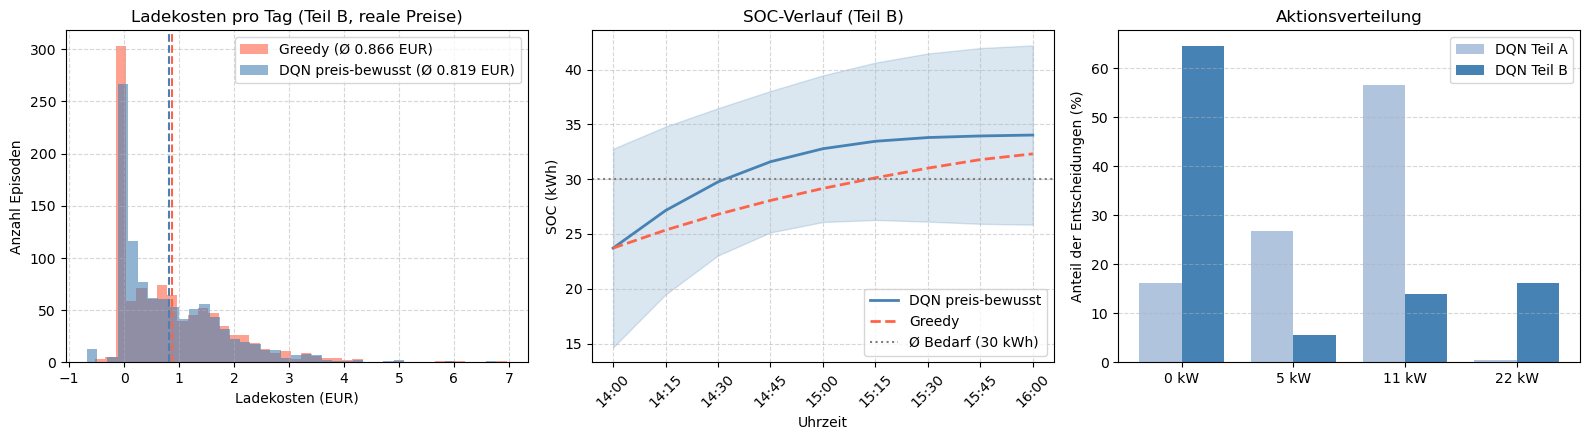

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Kostenverteilung Greedy vs preis-bewusster DQN (Teil B)
ax[0].hist(grdB_c, bins=40, alpha=0.6, color='tomato', label=f'Greedy (Ø {grdB_c.mean():.3f} EUR)')
ax[0].hist(dqnB_c, bins=40, alpha=0.6, color='steelblue', label=f'DQN preis-bewusst (Ø {dqnB_c.mean():.3f} EUR)')
ax[0].axvline(grdB_c.mean(), color='tomato', ls='--'); ax[0].axvline(dqnB_c.mean(), color='steelblue', ls='--')
ax[0].set_title('Ladekosten pro Tag (Teil B, reale Preise)')
ax[0].set_xlabel('Ladekosten (EUR)'); ax[0].set_ylabel('Anzahl Episoden')
ax[0].legend(); ax[0].grid(True, ls='--', alpha=0.5)

# (2) SOC-Trajektorien Teil B: DQN vs Greedy
times = [14.0 + i*0.25 for i in range(9)]
ax[1].plot(times, dqnB_traj.mean(0), color='steelblue', lw=2, label='DQN preis-bewusst')
ax[1].fill_between(times, dqnB_traj.mean(0)-dqnB_traj.std(0), dqnB_traj.mean(0)+dqnB_traj.std(0),
                   color='steelblue', alpha=0.2)
ax[1].plot(times, grdB_traj.mean(0), color='tomato', lw=2, ls='--', label='Greedy')
ax[1].axhline(30, color='gray', ls=':', label='Ø Bedarf (30 kWh)')
ax[1].set_title('SOC-Verlauf (Teil B)')
ax[1].set_xlabel('Uhrzeit'); ax[1].set_ylabel('SOC (kWh)')
ax[1].set_xticks(times); ax[1].set_xticklabels([f'{int(t)}:{int((t%1)*60):02d}' for t in times], rotation=45)
ax[1].legend(); ax[1].grid(True, ls='--', alpha=0.5)

# (3) Aktionsverteilung beider DQN
labels = ['0 kW', '5 kW', '11 kW', '22 kW']
x = np.arange(len(labels)); w = 0.38
ax[2].bar(x - w/2, dqnA_actions/dqnA_actions.sum()*100, w, color='lightsteelblue', label='DQN Teil A')
ax[2].bar(x + w/2, dqnB_actions/dqnB_actions.sum()*100, w, color='steelblue', label='DQN Teil B')
ax[2].set_xticks(x); ax[2].set_xticklabels(labels)
ax[2].set_title('Aktionsverteilung'); ax[2].set_ylabel('Anteil der Entscheidungen (%)')
ax[2].legend(); ax[2].grid(True, axis='y', ls='--', alpha=0.5)

plt.tight_layout(); plt.show()

### 14. Lernkurven beider Agenten

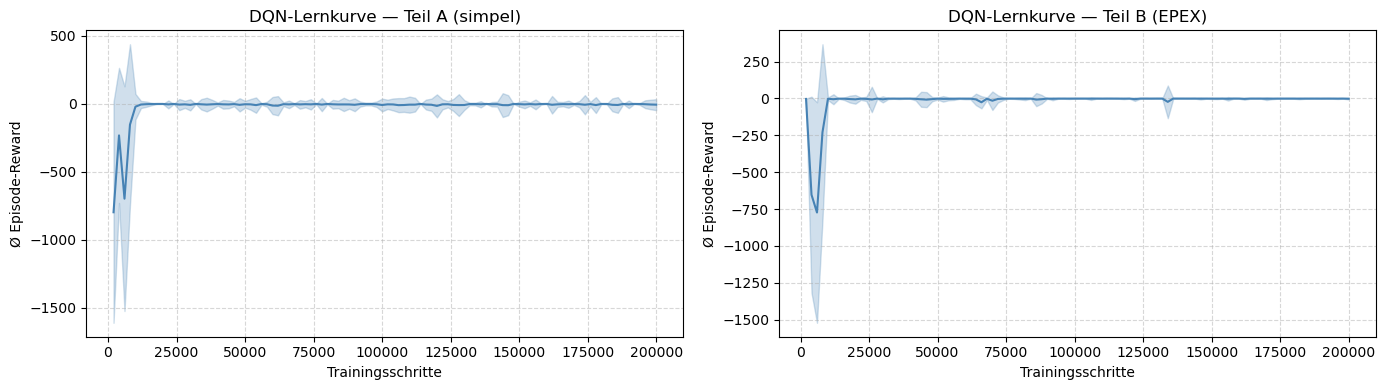

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, (path, title) in enumerate([('./logs/log_A/evaluations.npz', 'Teil A (simpel)'),
                                    ('./logs/log_B/evaluations.npz', 'Teil B (EPEX)')]):
    try:
        d = np.load(path)
        t = d['timesteps']; m = d['results'].mean(1); s = d['results'].std(1)
        ax[i].plot(t, m, color='steelblue'); ax[i].fill_between(t, m-s, m+s, color='steelblue', alpha=0.25)
        ax[i].set_title(f'DQN-Lernkurve — {title}')
        ax[i].set_xlabel('Trainingsschritte'); ax[i].set_ylabel('Ø Episode-Reward')
        ax[i].grid(True, ls='--', alpha=0.5)
    except FileNotFoundError:
        ax[i].text(0.5, 0.5, 'Keine Logs gefunden', ha='center', va='center')
plt.tight_layout(); plt.show()

---
### 15. Vertiefende Diagnostik

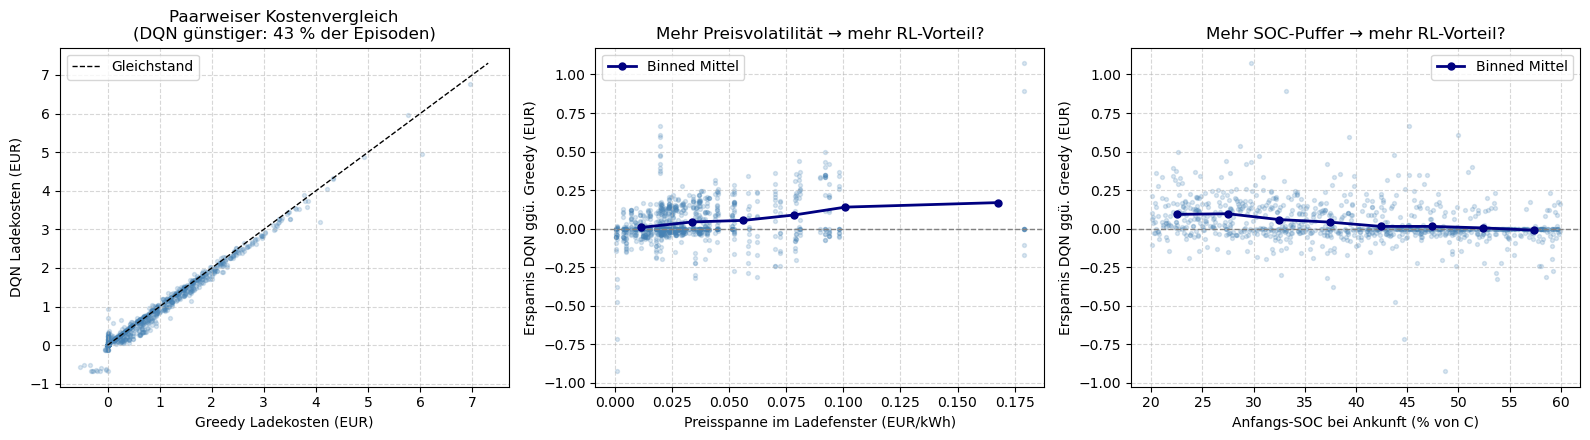

DQN günstiger: 409/957 Episoden (43%)


In [19]:
# Episoden-Metadaten via Seed-Reset re-extrahieren (kein Stepping noetig)
diag_env = TaxiChargingEnvEPEX(EPEX_WINDOWS)
meta_spread, meta_soc_frac = [], []
for sd in eval_seeds:
    diag_env.reset(seed=int(sd))
    meta_spread.append(float(diag_env.prices.max() - diag_env.prices.min()))
    meta_soc_frac.append(float(diag_env.initial_soc / diag_env.capacity * 100))
meta_spread   = np.array(meta_spread)
meta_soc_frac = np.array(meta_soc_frac)

ok         = dqnB_s & grdB_s
savings_ok = (grdB_c - dqnB_c)[ok]

def binned_mean(x, y, n_bins=8):
    """Mittelwert von y in n gleichbreiten x-Bins (mindestens 5 Punkte pro Bin)."""
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    cx, cy = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (x >= lo) & (x <= hi)
        if m.sum() >= 5:
            cx.append((lo + hi) / 2)
            cy.append(y[m].mean())
    return np.array(cx), np.array(cy)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Paarweiser Kostenvergleich
ax[0].scatter(grdB_c[ok], dqnB_c[ok], alpha=0.2, s=8, color='steelblue')
lim = max(grdB_c[ok].max(), dqnB_c[ok].max()) * 1.05
ax[0].plot([0, lim], [0, lim], 'k--', lw=1, label='Gleichstand')
pct = (dqnB_c[ok] < grdB_c[ok]).mean() * 100
ax[0].set_xlabel('Greedy Ladekosten (EUR)')
ax[0].set_ylabel('DQN Ladekosten (EUR)')
ax[0].set_title(f'Paarweiser Kostenvergleich\n(DQN günstiger: {pct:.0f} % der Episoden)')
ax[0].legend()
ax[0].grid(True, ls='--', alpha=0.5)

# (2) Ersparnis nach Preisspanne im Ladefenster
ax[1].scatter(meta_spread[ok], savings_ok, alpha=0.2, s=8, color='steelblue')
ax[1].axhline(0, color='gray', ls='--', lw=1)
cx, cy = binned_mean(meta_spread[ok], savings_ok)
ax[1].plot(cx, cy, color='navy', lw=2, marker='o', ms=5, label='Binned Mittel')
ax[1].set_xlabel('Preisspanne im Ladefenster (EUR/kWh)')
ax[1].set_ylabel('Ersparnis DQN ggü. Greedy (EUR)')
ax[1].set_title('Mehr Preisvolatilität → mehr RL-Vorteil?')
ax[1].legend()
ax[1].grid(True, ls='--', alpha=0.5)

# (3) Ersparnis nach Anfangs-SOC
ax[2].scatter(meta_soc_frac[ok], savings_ok, alpha=0.2, s=8, color='steelblue')
ax[2].axhline(0, color='gray', ls='--', lw=1)
cx2, cy2 = binned_mean(meta_soc_frac[ok], savings_ok)
ax[2].plot(cx2, cy2, color='navy', lw=2, marker='o', ms=5, label='Binned Mittel')
ax[2].set_xlabel('Anfangs-SOC bei Ankunft (% von C)')
ax[2].set_ylabel('Ersparnis DQN ggü. Greedy (EUR)')
ax[2].set_title('Mehr SOC-Puffer → mehr RL-Vorteil?')
ax[2].legend()
ax[2].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(f'DQN günstiger: {(dqnB_c[ok] < grdB_c[ok]).sum()}/{ok.sum()} Episoden ({pct:.0f}%)')


C:\Users\Besitzer\AppData\Local\Temp\ipykernel_27496\2361422328.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


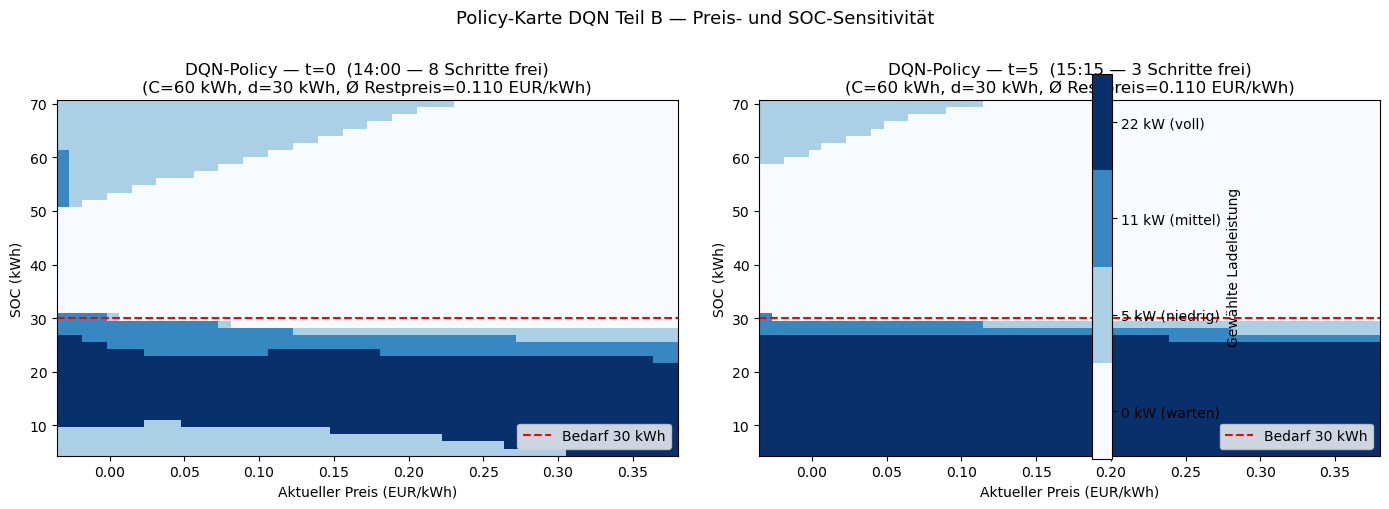

In [20]:
# Policy-Karte: Welche Leistung wählt DQN Teil B bei gegebenem (SOC, Preis)?
# Gezeigt fuer t=0 (viel Zeit, kein Druck) und t=5 (noch 3 Schritte, steigender Druck)
soc_vals   = np.linspace(5, 70, 50)
price_vals = np.linspace(EPEX_WINDOWS.min() - 0.005, EPEX_WINDOWS.max() + 0.005, 50)
C_fix, d_fix = 60.0, 30.0
med_p = float(np.median(EPEX_WINDOWS))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap_pol = plt.get_cmap('Blues', 4)

for col, (t_step, t_label) in enumerate([(0, 't=0  (14:00 — 8 Schritte frei)'),
                                          (5, 't=5  (15:15 — 3 Schritte frei)')]):
    grid = np.zeros((len(soc_vals), len(price_vals)), dtype=int)
    for i, soc in enumerate(soc_vals):
        for j, price in enumerate(price_vals):
            obs = np.array([soc, float(t_step), d_fix, C_fix, price, med_p], dtype=np.float32)
            grid[i, j] = int(model_B.predict(obs, deterministic=True)[0])

    im = axes[col].pcolormesh(price_vals, soc_vals, grid, cmap=cmap_pol, vmin=-0.5, vmax=3.5)
    axes[col].axhline(d_fix, color='red', ls='--', lw=1.5, label=f'Bedarf {int(d_fix)} kWh')
    axes[col].set_xlabel('Aktueller Preis (EUR/kWh)')
    axes[col].set_ylabel('SOC (kWh)')
    axes[col].set_title(f'DQN-Policy — {t_label}\n'
                         f'(C={int(C_fix)} kWh, d={int(d_fix)} kWh, '
                         f'Ø Restpreis={med_p:.3f} EUR/kWh)')
    axes[col].legend(loc='lower right')

cbar = plt.colorbar(im, ax=axes.tolist(), ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['0 kW (warten)', '5 kW (niedrig)', '11 kW (mittel)', '22 kW (voll)'])
cbar.set_label('Gewählte Ladeleistung')
plt.suptitle('Policy-Karte DQN Teil B — Preis- und SOC-Sensitivität', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


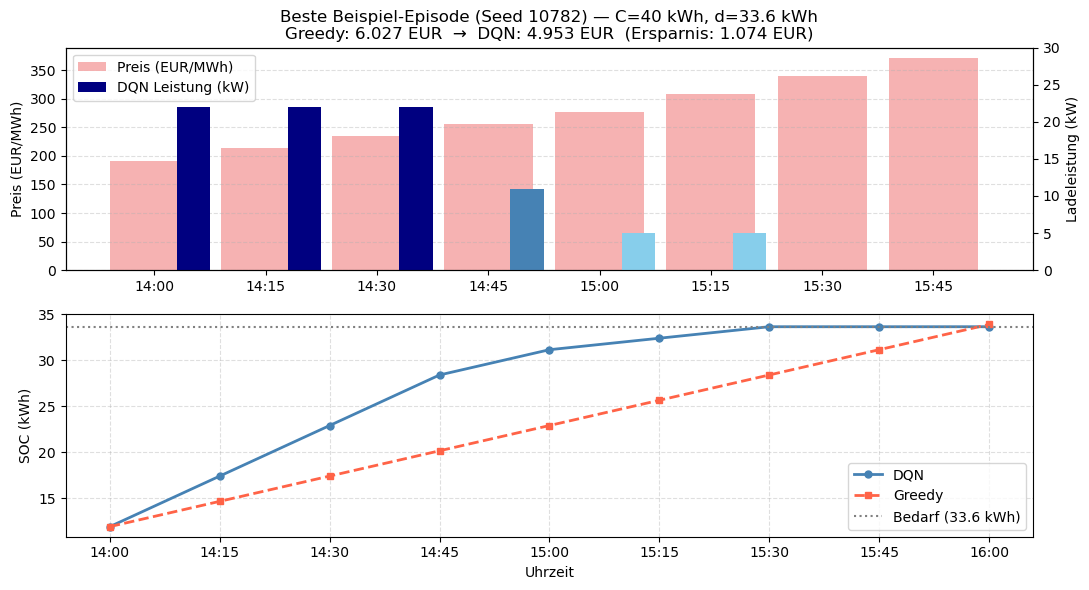

In [21]:
# Beste Episode: groesste absolute DQN-Ersparnis (beide Agenten erfolgreich)
ok_ep       = dqnB_s & grdB_s
savings_all = np.where(ok_ep, grdB_c - dqnB_c, -np.inf)
best_idx    = int(np.argmax(savings_all))
best_seed   = int(eval_seeds[best_idx])

# DQN-Lauf mit Detail-Tracking
ep_env = TaxiChargingEnvEPEX(EPEX_WINDOWS)
obs, _ = ep_env.reset(seed=best_seed)
prices_ep = ep_env.prices.copy()
cap_ep, demand_ep = ep_env.capacity, ep_env.demand
soc_dqn, powers_ep, costs_ep = [ep_env.soc], [], []
done = False
while not done:
    action, _ = model_B.predict(obs, deterministic=True)
    obs, _, done, _, info = ep_env.step(int(action))
    powers_ep.append(info['power'])
    costs_ep.append(info['charging_cost'])
    soc_dqn.append(ep_env.soc)

# Greedy-Lauf auf identischem Seed
grd_ep_env = TaxiChargingEnvEPEX(EPEX_WINDOWS)
_, cost_grd_ep, _, soc_grd = greedy_episode_epex(grd_ep_env, seed=best_seed)

step_ticks = ['14:00','14:15','14:30','14:45','15:00','15:15','15:30','15:45']
full_ticks  = step_ticks + ['16:00']
power_color = {0: 'lightgray', 5: 'skyblue', 11: 'steelblue', 22: 'navy'}

fig, ax = plt.subplots(2, 1, figsize=(11, 6))

# Oben: Preis-Profil (Balken) + DQN-Ladeleistung (Balken, farbig nach Leistungsstufe)
ax[0].bar(range(8), np.array(prices_ep) * 1000, color='lightcoral', alpha=0.6,
          label='Preis (EUR/MWh)')
ax0r = ax[0].twinx()
ax0r.bar([x + 0.35 for x in range(8)], powers_ep, width=0.3,
         color=[power_color[p] for p in powers_ep], label='DQN Leistung (kW)')
ax0r.set_ylabel('Ladeleistung (kW)')
ax0r.set_ylim(0, 30)
ax[0].set_ylabel('Preis (EUR/MWh)')
ax[0].set_xticks(range(8))
ax[0].set_xticklabels(step_ticks)
total_dqn = sum(costs_ep)
ax[0].set_title(f'Beste Beispiel-Episode (Seed {best_seed}) — '
                f'C={int(cap_ep)} kWh, d={demand_ep:.1f} kWh\n'
                f'Greedy: {cost_grd_ep:.3f} EUR  →  DQN: {total_dqn:.3f} EUR  '
                f'(Ersparnis: {cost_grd_ep - total_dqn:.3f} EUR)')
l0, lb0   = ax[0].get_legend_handles_labels()
l0r, lb0r = ax0r.get_legend_handles_labels()
ax[0].legend(l0 + l0r, lb0 + lb0r, loc='upper left')
ax[0].grid(True, axis='y', ls='--', alpha=0.4)

# Unten: SOC-Verlauf DQN vs Greedy
ax[1].plot(range(9), soc_dqn, color='steelblue', lw=2, marker='o', ms=5, label='DQN')
ax[1].plot(range(9), soc_grd, color='tomato',    lw=2, ls='--', marker='s', ms=4, label='Greedy')
ax[1].axhline(demand_ep, color='gray', ls=':', lw=1.5, label=f'Bedarf ({demand_ep:.1f} kWh)')
ax[1].set_xticks(range(9))
ax[1].set_xticklabels(full_ticks)
ax[1].set_xlabel('Uhrzeit')
ax[1].set_ylabel('SOC (kWh)')
ax[1].legend()
ax[1].grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()


---
## 16. Interpretation und Implikationen für den Flottenbetreiber

**Das zentrale Ergebnis der 3 Angehensweisen**

- **Teil A (vereinfachtes Kostenmodell):** DQN und Greedy liegen praktisch gleichauf und beide nahe am
  Brute-Force-Optimum. Wenn jede kWh quasi gleich viel kostet, ist „fehlenden Bedarf gleichmäßig auffüllen"
  bereits nahezu optimal — **RL bringt hier keinen Mehrwert.

- **Teil B (reale EPEX-Preise):** Sobald die Preise über den Tag schwanken und der Agent den Preis im Zustand
  sieht, **lernt der DQN, Ladevorgänge in günstige Schritte zu verschieben** und teure zu vermeiden — bei
  gleichbleibend hoher Erfolgsquote. Die preis-blinde Greedy-Heuristik kann das nicht und zahlt im Schnitt mehr.
  bei niedrigem Preis und SOC unter Bedarf
  wird voll geladen; bei hohem Preis wird gewartet, sofern noch Zeit bleibt. **hier lohnt sich RL.**

**Wann lohnt sich Smart Charging?** **Je stärker die Preise schwanken,
desto größer der RL-Vorteil.** Bei flachen Tarifen genügt eine Regel; bei dynamischen Day-Ahead- oder
Intraday-Tarifen wird die preis-bewusste Steuerung wertvoll. ref.(Abschnitt 15.1)

**Private vs. öffentliche Ladeinfrastruktur.** Da das Laden zu Hause (14–16 Uhr) eine planbare, steuerbare
Ladephase ist, kann der Betreiber mit **eigener Ladeinfrastruktur und dynamischem Tarif** die günstigen
Day-Ahead-Fenster gezielt ausnutzen — ein Vorteil, den öffentliche Ladesäulen mit festen, meist höheren
Tarifen nicht bieten. Smart Charging ist also vor allem im Zusammenspiel mit **eigener Wallbox plus
dynamischem Stromvertrag oder eigener Produktion** attraktiv.